# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Anggara Mohammad Sahid (isi dengan nama lengkap Anda)  
**NIM:** 122400028 (isi dengan NIM Anda)  

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


Ukuran gambar asli: (3264, 2448, 3)


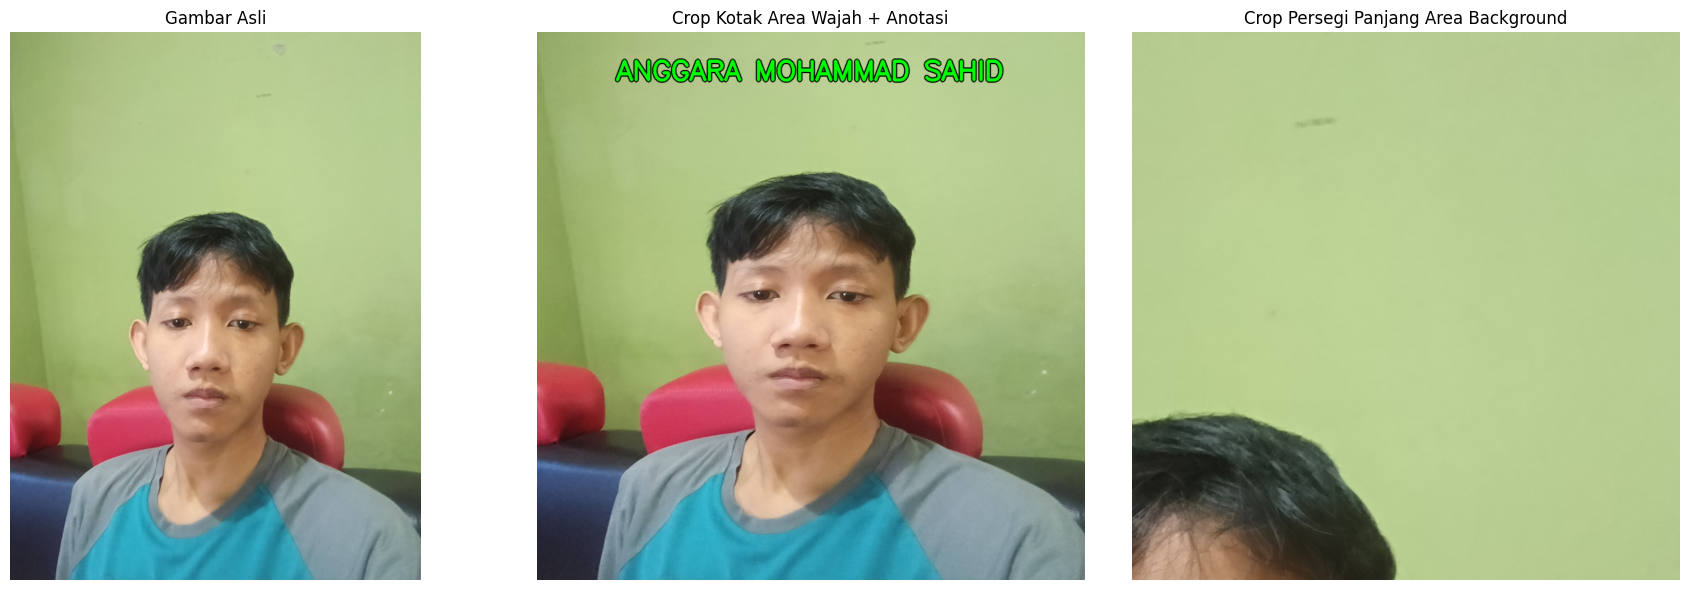

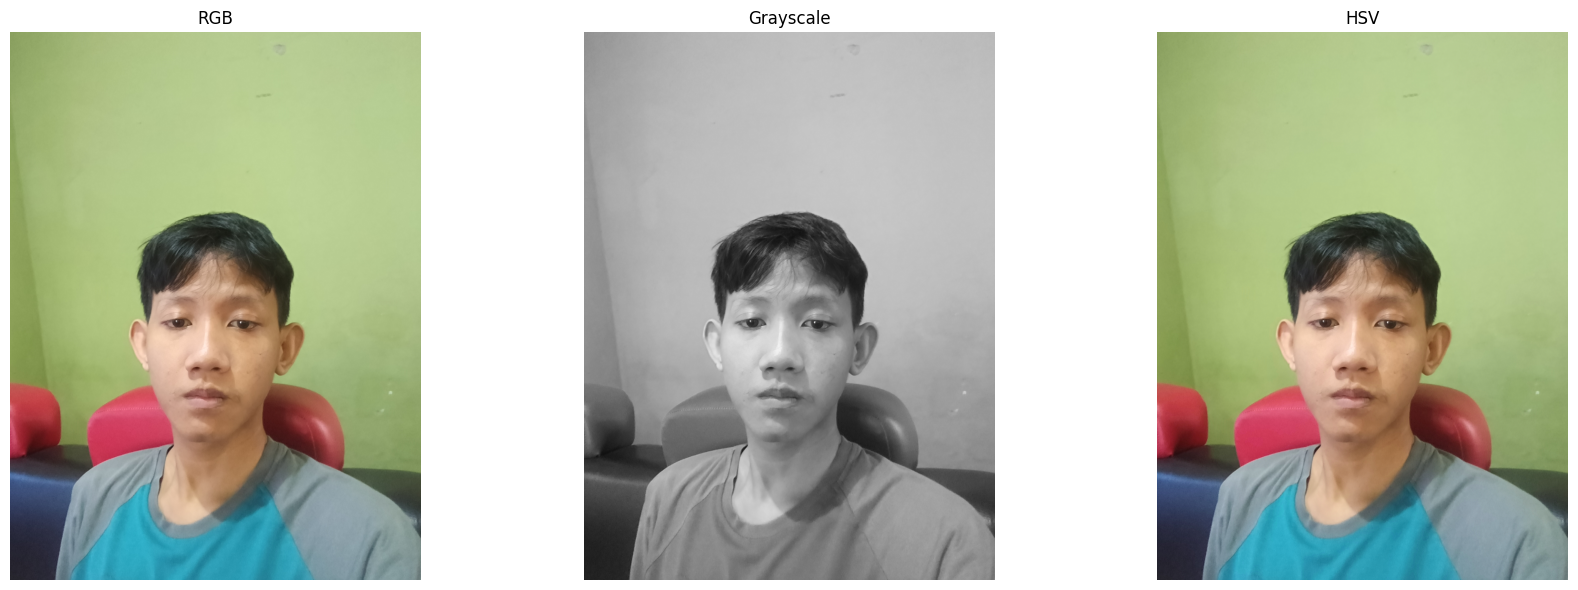

Semua hasil gambar berhasil disimpan.


In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Membaca gambar
# ==============================

NAMA = "ANGGARA MOHAMMAD SAHID"

img_path = os.path.join(os.getcwd(), 'data', 'selfie.png')

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan. Pastikan nama file dan path sudah benar.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Ukuran gambar asli:", img.shape)

h, w = img.shape[:2]

# ==============================
# 2. Deteksi wajah otomatis
# ==============================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(60, 60)
)

# Jika wajah terdeteksi
if len(faces) > 0:
    # Ambil wajah terbesar
    x, y, fw, fh = max(faces, key=lambda box: box[2] * box[3])

    # Tambahkan padding agar kepala dan sekitar wajah ikut masuk
    padding_x = int(fw * 0.7)
    padding_y = int(fh * 0.9)

    x1_face = max(0, x - padding_x)
    y1_face = max(0, y - padding_y)
    x2_face = min(w, x + fw + padding_x)
    y2_face = min(h, y + fh + padding_y)

else:
    # Koordinat manual cadangan jika wajah tidak terdeteksi
    # Sesuai posisi wajah pada gambar Anda
    x1_face, y1_face = 60, 130
    x2_face, y2_face = 320, 430

# ==============================
# 3. Membuat crop wajah menjadi kotak
# ==============================

crop_w = x2_face - x1_face
crop_h = y2_face - y1_face

side = max(crop_w, crop_h)

center_x = (x1_face + x2_face) // 2
center_y = (y1_face + y2_face) // 2

x1_face = max(0, center_x - side // 2)
y1_face = max(0, center_y - side // 2)
x2_face = min(w, x1_face + side)
y2_face = min(h, y1_face + side)

# Koreksi jika crop keluar batas gambar
x1_face = max(0, x2_face - side)
y1_face = max(0, y2_face - side)

img_crop_face = img[y1_face:y2_face, x1_face:x2_face]

# ==============================
# 4. Crop background
# ==============================

# Area background di bagian kanan atas gambar
x1_bg = int(w * 0.45)
y1_bg = int(h * 0.05)
x2_bg = int(w * 0.95)
y2_bg = int(h * 0.45)

img_crop_bg = img[y1_bg:y2_bg, x1_bg:x2_bg]

# ==============================
# 5. Resize hasil crop menjadi 920 x 920
# ==============================

img_crop_face_resize = cv2.resize(img_crop_face, (920, 920))
img_crop_bg_resize = cv2.resize(img_crop_bg, (920, 920))

# ==============================
# 6. Menambahkan anotasi nama
# ==============================

img_annotated = img_crop_face_resize.copy()

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 1.5
thickness = 4

# Menyesuaikan ukuran teks agar tidak terpotong
while True:
    text_size, _ = cv2.getTextSize(NAMA, font, font_scale, thickness)
    text_w, text_h = text_size

    if text_w < img_annotated.shape[1] - 40:
        break

    font_scale -= 0.1

text_x = (img_annotated.shape[1] - text_w) // 2
text_y = 80

# Outline hitam agar teks lebih jelas
cv2.putText(
    img_annotated,
    NAMA,
    (text_x, text_y),
    font,
    font_scale,
    (0, 0, 0),
    thickness + 3,
    cv2.LINE_AA
)

# Teks hijau
cv2.putText(
    img_annotated,
    NAMA,
    (text_x, text_y),
    font,
    font_scale,
    (0, 255, 0),
    thickness,
    cv2.LINE_AA
)

# ==============================
# 7. Menampilkan hasil cropping
# ==============================

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

axs[1].imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
axs[1].set_title("Crop Kotak Area Wajah + Anotasi")
axs[1].axis("off")

axs[2].imshow(cv2.cvtColor(img_crop_bg_resize, cv2.COLOR_BGR2RGB))
axs[2].set_title("Crop Persegi Panjang Area Background")
axs[2].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 8. Konversi warna
# RGB, Grayscale, HSV
# ==============================

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

img_hsv_display = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)

# ==============================
# 9. Menampilkan RGB, Grayscale, HSV
# ==============================

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("RGB")
axs[0].axis("off")

axs[1].imshow(img_gray, cmap="gray")
axs[1].set_title("Grayscale")
axs[1].axis("off")

axs[2].imshow(img_hsv_display)
axs[2].set_title("HSV")
axs[2].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 10. Menyimpan hasil gambar
# ==============================

cv2.imwrite("hasil_crop_wajah_920x920.jpg", img_annotated)
cv2.imwrite("hasil_crop_background_920x920.jpg", img_crop_bg_resize)
cv2.imwrite("hasil_grayscale.jpg", img_gray)
cv2.imwrite("hasil_hsv.jpg", img_hsv)

print("Semua hasil gambar berhasil disimpan.")

## Penjelasan Efek Cropping dan Perubahan Warna

Cropping dilakukan untuk mengambil bagian tertentu dari citra digital. Pada crop kotak area wajah, informasi visual difokuskan pada objek utama yaitu wajah, sehingga bagian lain yang tidak diperlukan dihilangkan. Hal ini membuat perhatian pengamat lebih terarah pada subjek utama.

Cropping persegi panjang pada area latar belakang menunjukkan bahwa citra digital dapat dipotong berdasarkan koordinat piksel tertentu. Setiap bagian gambar memiliki informasi spasial yang dapat dipilih menggunakan batas koordinat x dan y.

Konversi warna ke grayscale menghilangkan informasi warna dan hanya mempertahankan intensitas cahaya. Akibatnya gambar terlihat dalam tingkat keabuan dari hitam hingga putih. Grayscale berguna untuk analisis bentuk, tekstur, dan kontras.

Konversi ke HSV memisahkan warna berdasarkan Hue, Saturation, dan Value. Representasi ini membuat perbedaan warna lebih mudah diamati dibandingkan RGB, terutama untuk analisis warna tertentu pada citra digital.

Dari hasil percobaan, dapat disimpulkan bahwa cropping memengaruhi fokus visual dan informasi spasial gambar, sedangkan perubahan ruang warna memengaruhi cara warna dan intensitas citra direpresentasikan.

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


Ukuran gambar crop: (920, 920, 3)


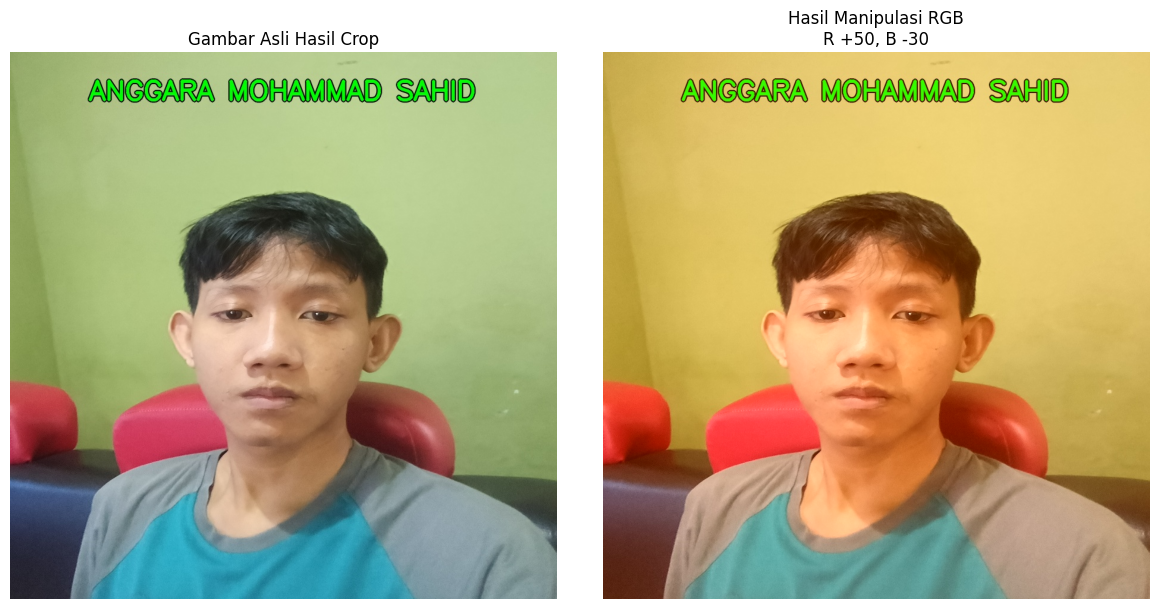

Gambar hasil modifikasi berhasil disimpan sebagai hasil_modifikasi_rgb.png


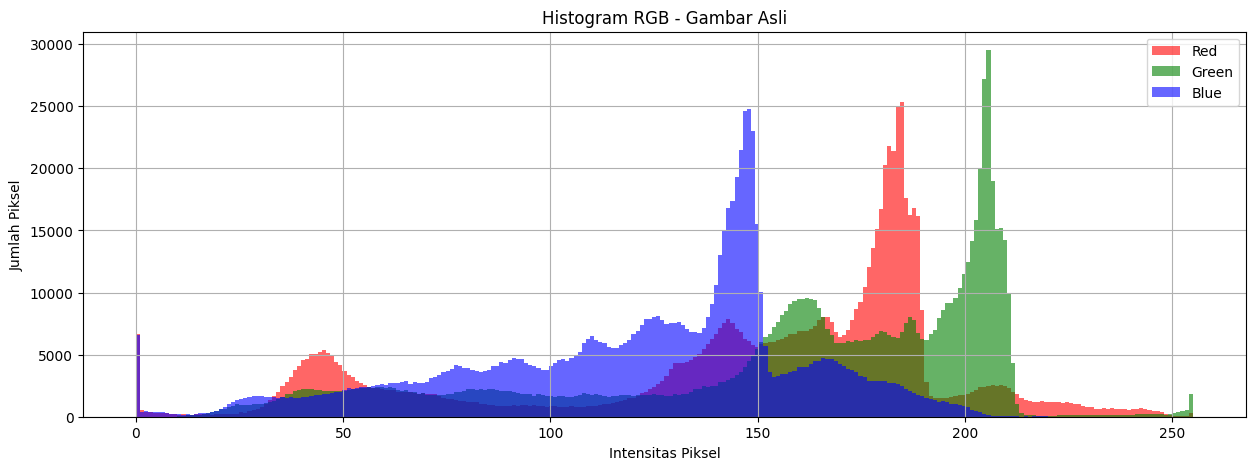

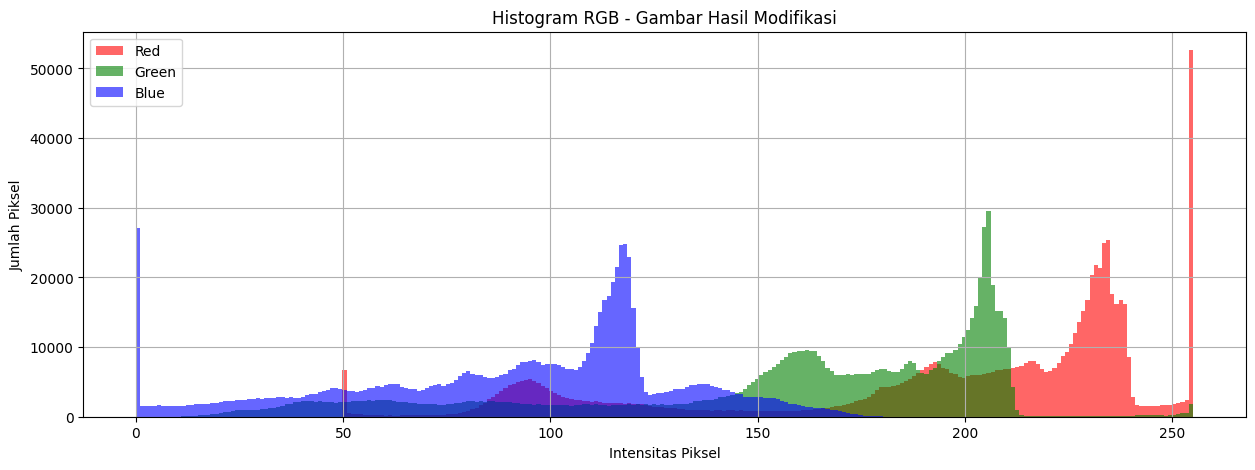

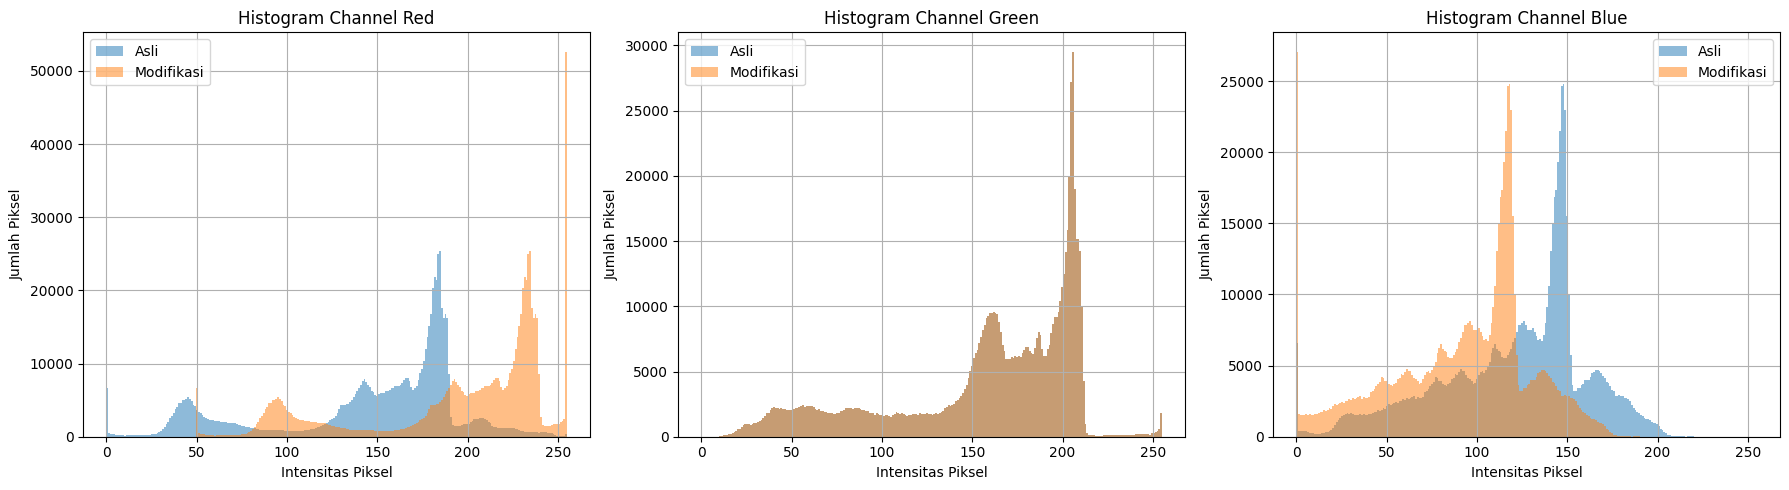

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Membaca gambar hasil crop Soal 1
# ==============================

# Gunakan gambar hasil crop dari Soal 1
img_path = "hasil_crop_wajah_920x920.jpg"

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError("Gambar hasil crop tidak ditemukan. Pastikan file hasil_crop_wajah_920x920.jpg sudah ada.")

# OpenCV membaca gambar dalam format BGR
# Konversi ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Ukuran gambar crop:", img_rgb.shape)

# ==============================
# 2. Memisahkan channel RGB
# ==============================

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

# ==============================
# 3. Manipulasi channel warna
# ==============================

# Naikkan intensitas channel merah sebanyak 50 poin
R_mod = np.clip(R.astype(np.int16) + 50, 0, 255).astype(np.uint8)

# Channel hijau tetap
G_mod = G.copy()

# Turunkan intensitas channel biru sebanyak 30 poin
B_mod = np.clip(B.astype(np.int16) - 30, 0, 255).astype(np.uint8)

# ==============================
# 4. Gabungkan kembali channel RGB
# ==============================

img_rgb_mod = cv2.merge([R_mod, G_mod, B_mod])

# ==============================
# 5. Menampilkan gambar asli dan hasil modifikasi
# ==============================

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli Hasil Crop")
axs[0].axis("off")

axs[1].imshow(img_rgb_mod)
axs[1].set_title("Hasil Manipulasi RGB\nR +50, B -30")
axs[1].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 6. Menyimpan hasil modifikasi dalam format PNG
# ==============================

# Karena cv2.imwrite menggunakan format BGR,
# gambar RGB harus dikonversi kembali ke BGR sebelum disimpan
img_bgr_mod = cv2.cvtColor(img_rgb_mod, cv2.COLOR_RGB2BGR)

cv2.imwrite("hasil_modifikasi_rgb.png", img_bgr_mod)

print("Gambar hasil modifikasi berhasil disimpan sebagai hasil_modifikasi_rgb.png")

# ==============================
# 7. Histogram per channel RGB
# ==============================

channels = ["Red", "Green", "Blue"]
colors = ["red", "green", "blue"]

# Histogram gambar asli
plt.figure(figsize=(15, 5))

for i, color in enumerate(colors):
    plt.hist(
        img_rgb[:, :, i].ravel(),
        bins=256,
        range=(0, 255),
        color=color,
        alpha=0.6,
        label=channels[i]
    )

plt.title("Histogram RGB - Gambar Asli")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.legend()
plt.grid(True)
plt.show()

# Histogram gambar hasil modifikasi
plt.figure(figsize=(15, 5))

for i, color in enumerate(colors):
    plt.hist(
        img_rgb_mod[:, :, i].ravel(),
        bins=256,
        range=(0, 255),
        color=color,
        alpha=0.6,
        label=channels[i]
    )

plt.title("Histogram RGB - Gambar Hasil Modifikasi")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.legend()
plt.grid(True)
plt.show()

# ==============================
# 8. Histogram perbandingan asli dan modifikasi per channel
# ==============================

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, color in enumerate(colors):
    axs[i].hist(
        img_rgb[:, :, i].ravel(),
        bins=256,
        range=(0, 255),
        alpha=0.5,
        label="Asli"
    )

    axs[i].hist(
        img_rgb_mod[:, :, i].ravel(),
        bins=256,
        range=(0, 255),
        alpha=0.5,
        label="Modifikasi"
    )

    axs[i].set_title(f"Histogram Channel {channels[i]}")
    axs[i].set_xlabel("Intensitas Piksel")
    axs[i].set_ylabel("Jumlah Piksel")
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()

## Penjelasan Dampak Perubahan RGB

Pada gambar hasil modifikasi, channel merah dinaikkan sebesar 50 poin sehingga warna merah pada gambar menjadi lebih kuat. Akibatnya, gambar terlihat lebih hangat dan memiliki nuansa kemerahan.

Channel biru diturunkan sebesar 30 poin sehingga intensitas warna biru pada gambar berkurang. Hal ini membuat gambar terlihat kurang dingin dan warna seperti kuning, oranye, atau merah menjadi lebih dominan.

Pada histogram, channel merah mengalami pergeseran ke arah intensitas yang lebih tinggi, sedangkan channel biru bergeser ke arah intensitas yang lebih rendah. Channel hijau tidak mengalami perubahan karena nilainya tetap sama seperti gambar asli.

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


Ukuran gambar: (1086, 1448, 3)


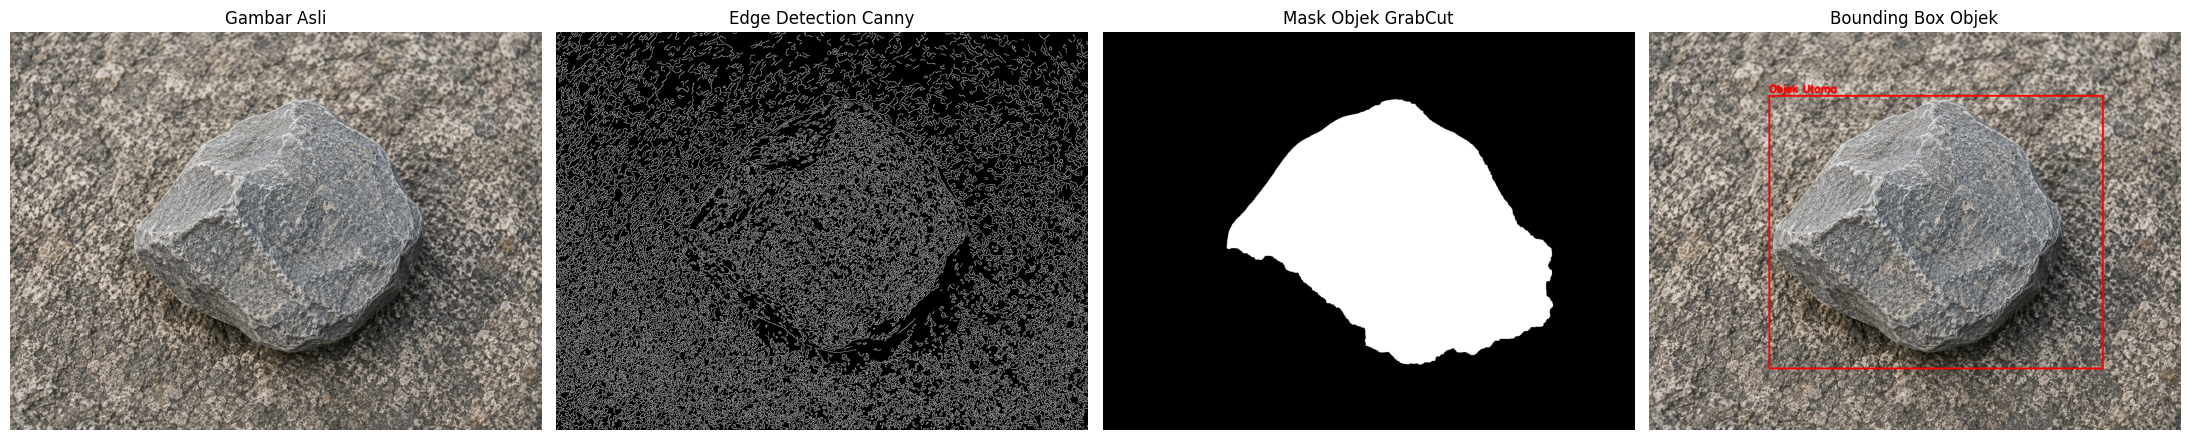

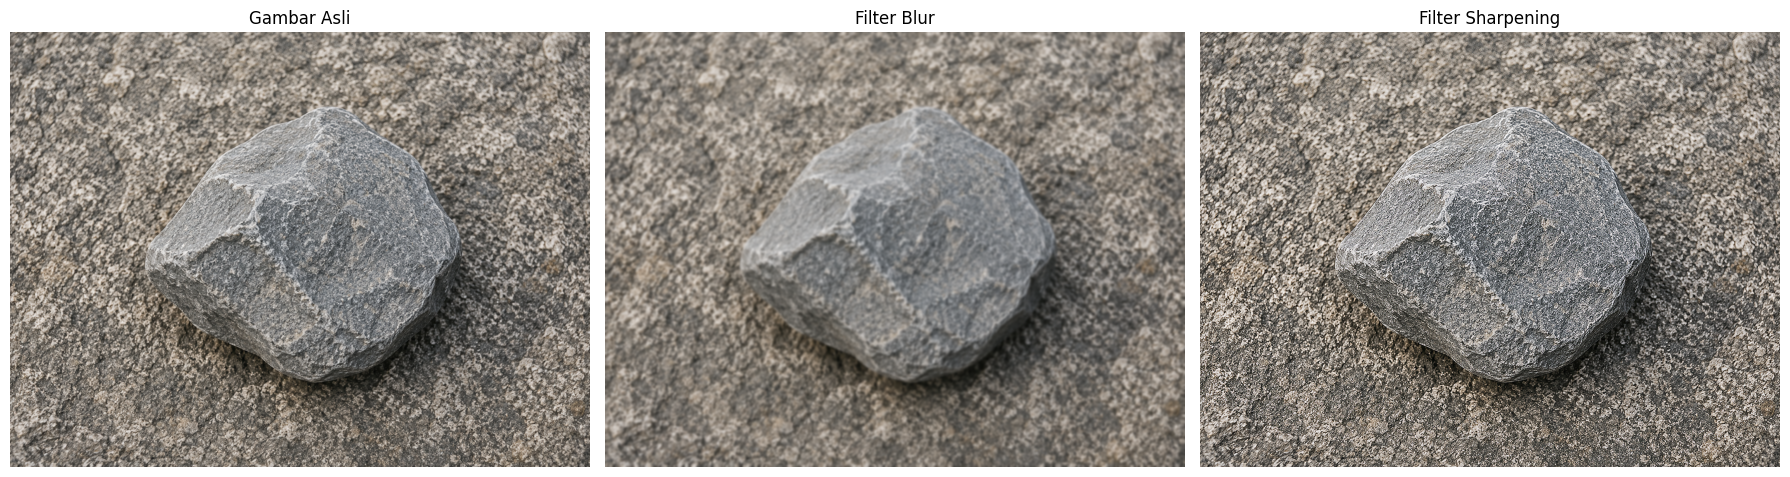

Semua hasil gambar berhasil disimpan.


In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Membaca gambar
# ==============================

# Ganti nama file sesuai gambar Anda
# Contoh: objek dengan background bertekstur seperti kain, batu, jerami, dll.
img_path = os.path.join(os.getcwd(), 'data', 'batu.png')

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan. Pastikan path dan nama file sudah benar.")

# OpenCV membaca gambar dalam format BGR
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Ukuran gambar:", img.shape)

# ==============================
# 2. Konversi ke Grayscale
# ==============================

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==============================
# 3. Edge Detection Canny
# ==============================

# Blur ringan agar noise tekstur background sedikit berkurang
gray_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Canny edge detection
edges = cv2.Canny(gray_blur, 80, 160)

# ==============================
# 4. Segmentasi Objek dengan GrabCut
# ==============================

# Salin gambar asli
img_grabcut = img.copy()

# Buat mask kosong
mask = np.zeros(img.shape[:2], np.uint8)

# Model background dan foreground untuk GrabCut
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

h, w = img.shape[:2]

# Rectangle awal untuk objek
# Sesuaikan jika posisi objek berbeda
# Format: (x, y, width, height)
rect = (
    int(w * 0.15),   # x awal
    int(h * 0.15),   # y awal
    int(w * 0.70),   # lebar area
    int(h * 0.70)    # tinggi area
)

# Jalankan GrabCut
cv2.grabCut(
    img_grabcut,
    mask,
    rect,
    bgd_model,
    fgd_model,
    5,
    cv2.GC_INIT_WITH_RECT
)

# Ambil area foreground
mask_objek = np.where(
    (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
    255,
    0
).astype("uint8")

# ==============================
# 5. Membersihkan Mask Objek
# ==============================

kernel = np.ones((7, 7), np.uint8)

# Hilangkan noise kecil
mask_objek = cv2.morphologyEx(mask_objek, cv2.MORPH_OPEN, kernel)

# Tutup lubang pada objek
mask_objek = cv2.morphologyEx(mask_objek, cv2.MORPH_CLOSE, kernel)

# ==============================
# 6. Membuat Bounding Box yang Lebih Pas
# ==============================

contours, _ = cv2.findContours(
    mask_objek,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

img_bbox = img_rgb.copy()

if len(contours) > 0:
    # Ambil contour terbesar sebagai objek utama
    largest_contour = max(contours, key=cv2.contourArea)

    # Bounding box dari contour terbesar
    x, y, bw, bh = cv2.boundingRect(largest_contour)

    # Tambahkan sedikit padding agar tidak terlalu mepet
    padding = 10

    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(w, x + bw + padding)
    y2 = min(h, y + bh + padding)

    # Gambar bounding box
    cv2.rectangle(
        img_bbox,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        4
    )

    cv2.putText(
        img_bbox,
        "Objek Utama",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (255, 0, 0),
        3,
        cv2.LINE_AA
    )

else:
    print("Objek tidak ditemukan. Coba ubah nilai rect pada GrabCut.")

# ==============================
# 7. Filter Blur
# ==============================

# Gaussian Blur
img_blur = cv2.GaussianBlur(img_rgb, (15, 15), 0)

# ==============================
# 8. Filter Sharpening
# ==============================

# Kernel sharpening
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

img_sharpen = cv2.filter2D(img_rgb, -1, kernel_sharpen)

# ==============================
# 9. Menampilkan Canny, Threshold, dan Bounding Box
# ==============================

fig, axs = plt.subplots(1, 4, figsize=(22, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

axs[1].imshow(edges, cmap="gray")
axs[1].set_title("Edge Detection Canny")
axs[1].axis("off")

axs[2].imshow(mask_objek, cmap="gray")
axs[2].set_title("Mask Objek GrabCut")
axs[2].axis("off")

axs[3].imshow(img_bbox)
axs[3].set_title("Bounding Box Objek")
axs[3].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 10. Menampilkan Perbandingan Blur dan Sharpening
# ==============================

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

axs[1].imshow(img_blur)
axs[1].set_title("Filter Blur")
axs[1].axis("off")

axs[2].imshow(img_sharpen)
axs[2].set_title("Filter Sharpening")
axs[2].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 11. Menyimpan hasil gambar
# ==============================

cv2.imwrite("hasil_canny.png", edges)
cv2.imwrite("hasil_threshold.png", thresh_clean)
cv2.imwrite("hasil_bounding_box.png", cv2.cvtColor(img_bbox, cv2.COLOR_RGB2BGR))
cv2.imwrite("hasil_blur.png", cv2.cvtColor(img_blur, cv2.COLOR_RGB2BGR))
cv2.imwrite("hasil_sharpening.png", cv2.cvtColor(img_sharpen, cv2.COLOR_RGB2BGR))

print("Semua hasil gambar berhasil disimpan.")

## Penjelasan Deteksi Tepi dan Filter Citra

Pada tahap edge detection menggunakan metode Canny, bagian tepi objek dan tekstur background akan terlihat sebagai garis putih. Jika background memiliki tekstur yang kuat, maka Canny juga dapat mendeteksi banyak tepi pada background, bukan hanya pada objek utama.

Pada tahap thresholding, gambar diubah menjadi citra biner hitam-putih. Tujuannya adalah memisahkan objek utama dari background. Nilai ambang menggunakan metode Otsu agar pemisahan objek dan background dilakukan secara otomatis berdasarkan intensitas piksel.

Bounding box dibuat berdasarkan contour terbesar dari hasil thresholding. Dengan cara ini, objek utama dapat diberi kotak pembatas secara otomatis.

Filter blur membuat gambar menjadi lebih halus dan mengurangi detail kecil atau noise pada background. Namun, efeknya juga membuat tepi objek menjadi kurang tajam.

Filter sharpening meningkatkan ketajaman gambar. Detail pada objek dan tekstur background menjadi lebih jelas, tetapi noise atau tekstur kecil juga bisa terlihat lebih kuat.

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

Ukuran gambar selfie: (3264, 2448, 3)
Ukuran gambar filter: (360, 476, 4)


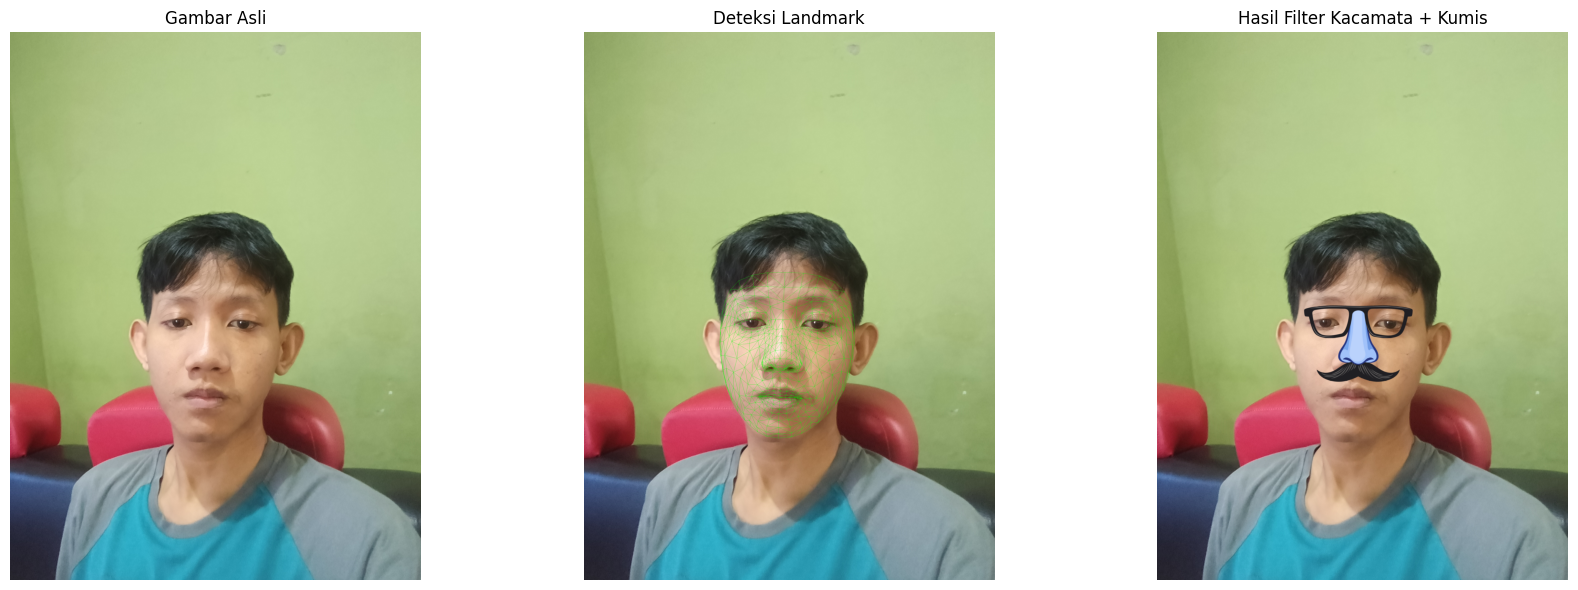

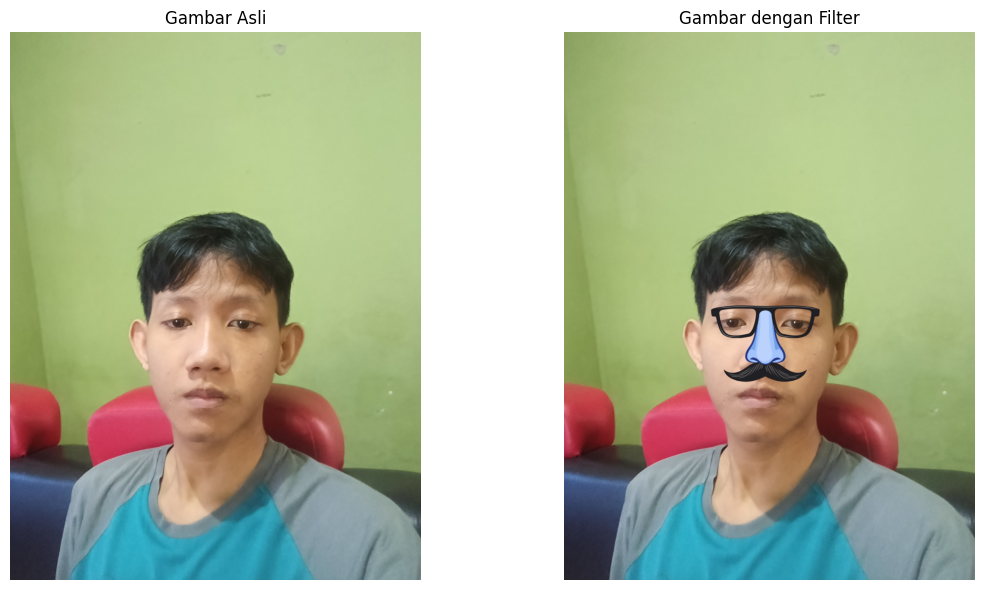

Hasil berhasil disimpan:
- hasil_landmark_wajah.png
- hasil_filter_kacamata.png


In [9]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Path file
# ==============================

img_path = os.path.join(os.getcwd(), "data", "selfie.png")
filter_path = os.path.join(os.getcwd(), "data", "kacamata.png")  
# kacamata.png di sini adalah gambar filter gabungan
# (sudah ada kacamata + kumis)

# ==============================
# 2. Membaca gambar
# ==============================

img_bgr = cv2.imread(img_path)
filter_png = cv2.imread(filter_path, cv2.IMREAD_UNCHANGED)  # harus PNG transparan

if img_bgr is None:
    raise FileNotFoundError("Gambar selfie tidak ditemukan. Cek file: data/selfie.png")

if filter_png is None:
    raise FileNotFoundError("Gambar filter tidak ditemukan. Cek file: data/kacamata.png")

if len(filter_png.shape) != 3 or filter_png.shape[2] != 4:
    raise ValueError("File filter harus PNG transparan (RGBA / 4 channel).")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_bgr.shape[:2]

print("Ukuran gambar selfie:", img_bgr.shape)
print("Ukuran gambar filter:", filter_png.shape)

# ==============================
# 3. Setup MediaPipe Face Mesh
# ==============================

mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

results = face_mesh.process(img_rgb)

img_landmark = img_rgb.copy()
img_result = img_rgb.copy()

# ==============================
# 4. Fungsi bantu
# ==============================

def get_point(landmarks, index, w, h):
    x = int(landmarks[index].x * w)
    y = int(landmarks[index].y * h)
    return (x, y)

def euclidean_distance(p1, p2):
    return int(np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2))

def resize_overlay_keep_aspect(overlay_rgba, target_width):
    oh, ow = overlay_rgba.shape[:2]
    scale = target_width / ow
    new_w = int(ow * scale)
    new_h = int(oh * scale)
    resized = cv2.resize(overlay_rgba, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized

def overlay_image_alpha(background_rgb, overlay_rgba, x, y):
    bg_h, bg_w = background_rgb.shape[:2]
    ov_h, ov_w = overlay_rgba.shape[:2]

    if x >= bg_w or y >= bg_h or x + ov_w <= 0 or y + ov_h <= 0:
        return background_rgb

    x1 = max(x, 0)
    y1 = max(y, 0)
    x2 = min(x + ov_w, bg_w)
    y2 = min(y + ov_h, bg_h)

    overlay_x1 = x1 - x
    overlay_y1 = y1 - y
    overlay_x2 = overlay_x1 + (x2 - x1)
    overlay_y2 = overlay_y1 + (y2 - y1)

    overlay_crop = overlay_rgba[overlay_y1:overlay_y2, overlay_x1:overlay_x2]

    overlay_rgb = overlay_crop[:, :, :3].astype(float)
    alpha = overlay_crop[:, :, 3].astype(float) / 255.0
    alpha = np.stack([alpha, alpha, alpha], axis=2)

    background_crop = background_rgb[y1:y2, x1:x2].astype(float)

    blended = alpha * overlay_rgb + (1 - alpha) * background_crop
    background_rgb[y1:y2, x1:x2] = blended.astype(np.uint8)

    return background_rgb

# ==============================
# 5. Deteksi wajah dan landmark
# ==============================

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        landmarks = face_landmarks.landmark

        # Gambar landmark
        mp_drawing.draw_landmarks(
            image=img_landmark,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing.DrawingSpec(
                color=(0, 255, 0),
                thickness=1,
                circle_radius=1
            )
        )

        # ------------------------------
        # Landmark penting
        # ------------------------------
        left_eye_outer = get_point(landmarks, 33, w, h)
        right_eye_outer = get_point(landmarks, 263, w, h)

        left_face = get_point(landmarks, 234, w, h)
        right_face = get_point(landmarks, 454, w, h)

        nose_tip = get_point(landmarks, 1, w, h)
        upper_lip = get_point(landmarks, 13, w, h)

        # Titik tengah kedua mata
        eye_center_x = (left_eye_outer[0] + right_eye_outer[0]) // 2
        eye_center_y = (left_eye_outer[1] + right_eye_outer[1]) // 2

        face_width = euclidean_distance(left_face, right_face)
        eye_distance = euclidean_distance(left_eye_outer, right_eye_outer)
        nose_to_lip = euclidean_distance(nose_tip, upper_lip)

        # ==============================
        # 6. Mengatur ukuran overlay
        # ==============================

        # Karena gambar filter berisi kacamata + kumis,
        # lebar overlay dibuat mengikuti lebar wajah
        filter_target_width = int(face_width * 0.85)

        filter_resized = resize_overlay_keep_aspect(filter_png, filter_target_width)
        fh, fw = filter_resized.shape[:2]

        # ==============================
        # 7. Mengatur posisi overlay
        # ==============================
        # Angka ini penting untuk menyesuaikan posisi bagian kacamata
        # di dalam file PNG gabungan.
        #
        # Misalnya, jika di gambar PNG:
        # - kacamata berada di sekitar 35% tinggi gambar,
        # maka gunakan 0.50
        #
        # Jika hasil masih belum pas, ubah nilai ini.
        GLASSES_CENTER_Y_RATIO = 0.27

        filter_x = eye_center_x - fw // 2
        filter_y = int(eye_center_y - fh * GLASSES_CENTER_Y_RATIO)

        img_result = overlay_image_alpha(img_result, filter_resized, filter_x, filter_y)

else:
    print("Wajah tidak terdeteksi. Gunakan gambar yang lebih jelas.")

# ==============================
# 8. Menampilkan hasil
# ==============================

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

axs[1].imshow(img_landmark)
axs[1].set_title("Deteksi Landmark")
axs[1].axis("off")

axs[2].imshow(img_result)
axs[2].set_title("Hasil Filter Kacamata + Kumis")
axs[2].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 9. Perbandingan gambar asli dan hasil
# ==============================

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(img_rgb)
axs[0].set_title("Gambar Asli")
axs[0].axis("off")

axs[1].imshow(img_result)
axs[1].set_title("Gambar dengan Filter")
axs[1].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 10. Menyimpan hasil
# ==============================

cv2.imwrite("hasil_landmark_wajah.png", cv2.cvtColor(img_landmark, cv2.COLOR_RGB2BGR))
cv2.imwrite("hasil_filter_kacamata.png", cv2.cvtColor(img_result, cv2.COLOR_RGB2BGR))

print("Hasil berhasil disimpan:")
print("- hasil_landmark_wajah.png")
print("- hasil_filter_kacamata.png")

## Penjelasan Deteksi Wajah dan Filter Digital Kreatif

Pada tugas ini, deteksi wajah dilakukan menggunakan MediaPipe Face Mesh. Landmark wajah digunakan untuk menentukan posisi overlay filter digital pada wajah.

Filter yang digunakan berupa satu gambar PNG transparan yang sudah berisi kacamata dan kumis. Posisi filter ditentukan berdasarkan titik mata kiri dan mata kanan, karena kacamata menjadi acuan utama untuk peletakan overlay.

Lebar overlay disesuaikan dengan lebar wajah agar ukuran filter terlihat proporsional. Titik tengah kedua mata digunakan sebagai pusat horizontal overlay, sedangkan posisi vertikal ditentukan dengan rasio tertentu agar bagian kacamata pada gambar PNG tepat berada di area mata.

Alpha blending digunakan agar bagian transparan dari file PNG tetap transparan dan filter tampak menyatu dengan gambar asli. Dengan teknik ini, hasil terlihat lebih natural.

Tantangan utamanya yaitu implementasi untuk menyesuaikan posisi vertikal overlay, karena file filter berisi beberapa elemen sekaligus dalam satu gambar. Oleh sebab itu, perlu penyesuaian rasio posisi agar kacamata dan kumis berada pada lokasi yang sesuai dengan wajah saya.

### **Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

* Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.
* Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:

  * Konversi ke **grayscale**.
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).
* Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.
* Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**).

Ukuran gambar: (3015, 3778, 3)


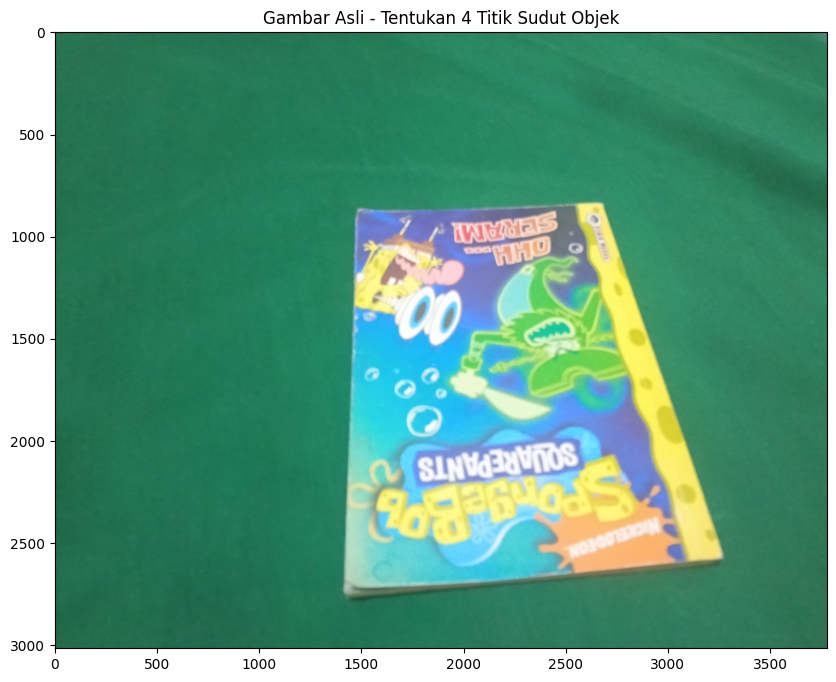

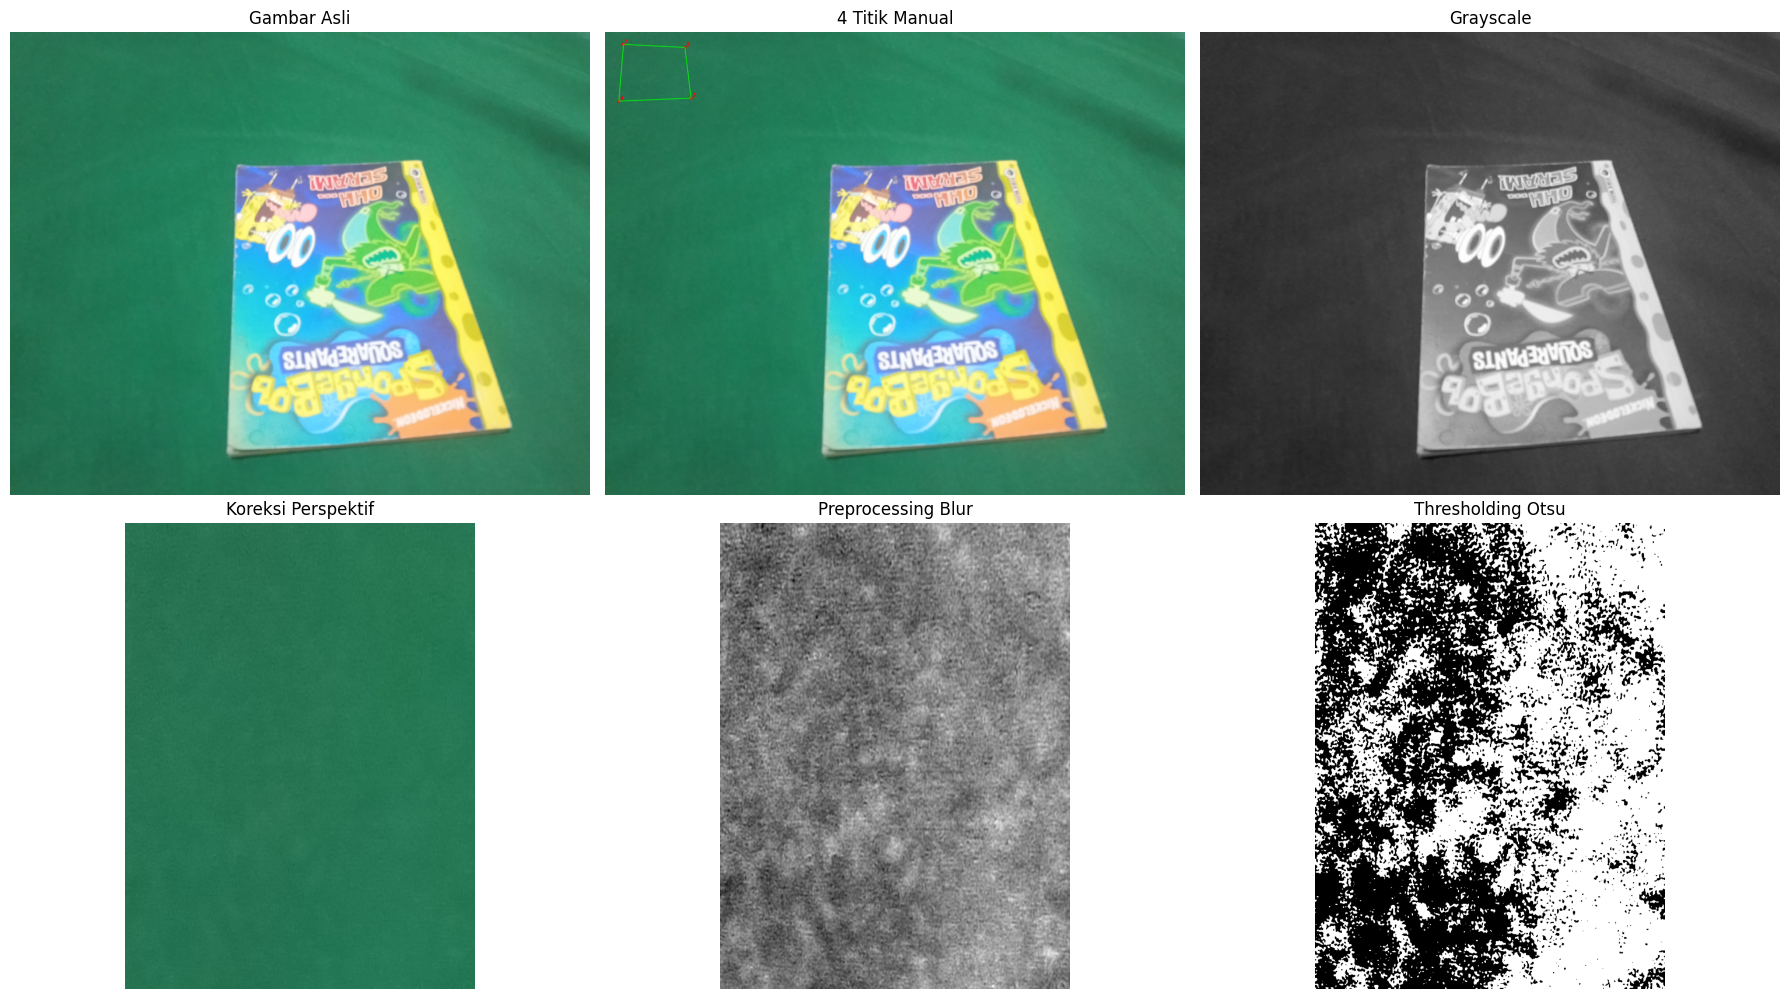

Semua hasil gambar berhasil disimpan.


In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================
# 1. Membaca gambar
# ==============================

img_path = os.path.join(os.getcwd(), "data", "objek.png")

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError("Gambar tidak ditemukan. Pastikan path dan nama file sudah benar.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Ukuran gambar:", img.shape)

# ==============================
# 2. Menampilkan gambar asli dengan sumbu koordinat
# ==============================
# Gunakan tampilan ini untuk melihat perkiraan titik sudut objek

plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Gambar Asli - Tentukan 4 Titik Sudut Objek")
plt.axis("on")
plt.show()

# ==============================
# 3. Konversi ke Grayscale
# ==============================

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==============================
# 4. Koreksi Perspektif / Homografi
# ==============================
# Format titik:
# kiri atas, kanan atas, kanan bawah, kiri bawah
#
# UBAH KOORDINAT DI BAWAH INI SESUAI GAMBAR ANDA

pts_src = np.float32([
    [120, 80],    # kiri atas
    [520, 100],   # kanan atas
    [560, 430],   # kanan bawah
    [90, 450]     # kiri bawah
])

# Ukuran hasil setelah perspektif diperbaiki
width = 600
height = 800

pts_dst = np.float32([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
])

# Matriks transformasi perspektif
matrix = cv2.getPerspectiveTransform(pts_src, pts_dst)

# Terapkan transformasi perspektif pada gambar RGB dan grayscale
img_warp_rgb = cv2.warpPerspective(img_rgb, matrix, (width, height))
img_warp_gray = cv2.warpPerspective(img_gray, matrix, (width, height))

# ==============================
# 5. Peningkatan kualitas citra
# ==============================
# Gaussian blur ringan untuk mengurangi noise

img_blur = cv2.GaussianBlur(img_warp_gray, (5, 5), 0)

# ==============================
# 6. Thresholding Otsu
# ==============================
# Otsu dipilih karena nilai threshold ditentukan otomatis
# berdasarkan distribusi intensitas piksel.

_, img_otsu = cv2.threshold(
    img_blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Jika hasil threshold terbalik, aktifkan baris ini
# img_otsu = cv2.bitwise_not(img_otsu)

# ==============================
# 7. Menampilkan titik sumber pada gambar asli
# ==============================

img_points = img_rgb.copy()

for i, point in enumerate(pts_src):
    x, y = int(point[0]), int(point[1])
    cv2.circle(img_points, (x, y), 10, (255, 0, 0), -1)
    cv2.putText(
        img_points,
        str(i + 1),
        (x + 10, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 0, 0),
        3,
        cv2.LINE_AA
    )

# Gambar garis penghubung antar titik
pts_line = pts_src.astype(np.int32).reshape((-1, 1, 2))
cv2.polylines(img_points, [pts_line], True, (0, 255, 0), 4)

# ==============================
# 8. Menampilkan semua tahap dalam satu grid
# ==============================

fig, axs = plt.subplots(2, 3, figsize=(18, 10))

axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title("Gambar Asli")
axs[0, 0].axis("off")

axs[0, 1].imshow(img_points)
axs[0, 1].set_title("4 Titik Manual")
axs[0, 1].axis("off")

axs[0, 2].imshow(img_gray, cmap="gray")
axs[0, 2].set_title("Grayscale")
axs[0, 2].axis("off")

axs[1, 0].imshow(img_warp_rgb)
axs[1, 0].set_title("Koreksi Perspektif")
axs[1, 0].axis("off")

axs[1, 1].imshow(img_blur, cmap="gray")
axs[1, 1].set_title("Preprocessing Blur")
axs[1, 1].axis("off")

axs[1, 2].imshow(img_otsu, cmap="gray")
axs[1, 2].set_title("Thresholding Otsu")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

# ==============================
# 9. Menyimpan hasil
# ==============================

cv2.imwrite("hasil_grayscale_soal5.png", img_gray)
cv2.imwrite("hasil_koreksi_perspektif.png", cv2.cvtColor(img_warp_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite("hasil_threshold_otsu.png", img_otsu)

print("Semua hasil gambar berhasil disimpan.")

## Penjelasan Tugas 5 — Perspektif dan Peningkatan Kualitas Citra

Pada tugas ini digunakan gambar objek datar berupa buku. Gambar diproses agar tampak lebih rapi, jelas, dan mudah dianalisis.

Pertama, gambar dikonversi ke grayscale agar proses pengolahan citra lebih sederhana karena hanya menggunakan satu channel intensitas.

Selanjutnya dilakukan koreksi perspektif menggunakan 4 titik manual pada sudut buku. Titik tersebut digunakan untuk mengubah tampilan buku yang miring menjadi lebih sejajar dan tidak terdistorsi. Pemilihan titik harus tepat pada sudut objek, karena jika titik berada di background maka hasil koreksi hanya akan menampilkan background.

Setelah itu, diterapkan Gaussian blur untuk mengurangi noise atau tekstur kecil pada gambar. Blur membantu membuat hasil thresholding menjadi lebih halus.

Thresholding Otsu digunakan untuk mengubah gambar menjadi hitam-putih. Metode ini dipilih karena nilai ambang ditentukan secara otomatis berdasarkan intensitas piksel pada gambar.

Secara keseluruhan, proses grayscale, koreksi perspektif, blur, dan thresholding dapat meningkatkan kualitas visual citra. Hasil akhir membuat objek terlihat lebih rapi dan lebih mudah diamati.

## Bukti Percakapan AI

![Bukti AI 1](data/bukti_ai_1.png)

![Bukti AI 2](data/bukti_ai_2.png)

![Bukti AI 3](data/bukti_ai_3.png)

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Source code antar mahasiswa harus berbeda.
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---

### ✅ **Catatan Akhir**

> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas.